In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sympy as sp
import scipy as sy
from scipy.integrate import odeint
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import root

## An Interacting Affine model of the dark sector

##### $P_X = w\rho_X-(1+w)\rho_\Lambda$ 
##### $w_x = w-(1+w)\frac{\rho_\Lambda}{\rho_X}$

### Using cosmological constant normalisation

$x =\frac{\rho_X}{\rho_\Lambda}$ , $y=\frac{\rho_m}{\rho_\Lambda}$

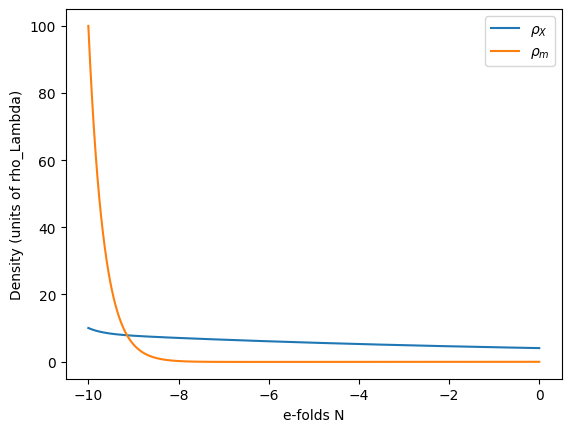

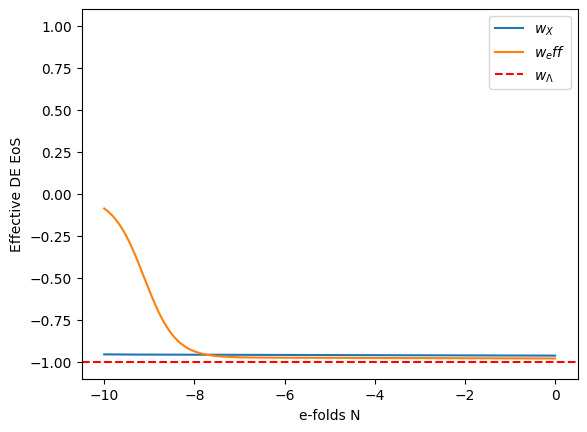

In [2]:
# Parameters to be optimised to lambda cdm data
w = -0.95
q = 0.05


def system(N, vars):
    x, y = vars

    w_x = w - (1 + w)/(x+1e-8)
    
    dx =-3*(1+w)*(x-1) + q*(x-y)
    dy =-3*y - q*(x-y)

    return [dx, dy]

N = np.linspace(-10, 0, 500) # -50 epochs is around the time of inflation but for observational data fitting i need to start today slightly back -10-0 epochs
sol = solve_ivp(system, [-10,0], [10,100] , t_eval=N)#  for initial conditions matter (y) now ~0.4 and so DM (x) ~0.6. For early time, large x for DE domination and 
#large y for matter epochs. Using present values, y(-50)=0.4e^(-3*-50) and x(-50)=0.6e^(-3(1+w))
x = sol.y[0]
y = sol.y[1]
a = np.exp(sol.t)  # scale factor


rho_X = x * 1  # assuming rho_Lambda = 1 in code units
rho_m = y * 1
rho_tot = rho_X + rho_m + 1
w_x = w - (1 + w)/(x+1e-8)
w_eff = (w*(x-1)-1) /(x+y)

plt.figure()
plt.plot(N, x, label=r'$\rho_X$')
plt.plot(N, y, label=r'$\rho_m$')
plt.xlabel('e-folds N')
plt.ylabel('Density (units of rho_Lambda)')
#plt.xscale('log')  # log scale to show early universe
plt.legend()

plt.figure()
plt.plot(N, w_x, label=r'$w_X$')
plt.plot(N, w_eff, label=r'$w_eff$')
plt.axhline(y=-1, color='r', linestyle='--', label=r'$w_\Lambda$')
plt.xlabel('e-folds N')
plt.ylabel('Effective DE EoS')
plt.ylim(-1.1,1.1)
#plt.xscale('log')
plt.legend()
plt.show()

Physical fixed points: [[1.0350877192982457, -0.017543859649122806]]
Fixed points (1.0350877192982457,-0.017543859649122806)
Eigen Values: [-1.44833518 -2.95166482]
Type=node
Stability=Attractor



/tmp/ipykernel_2206/90627675.py:126: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


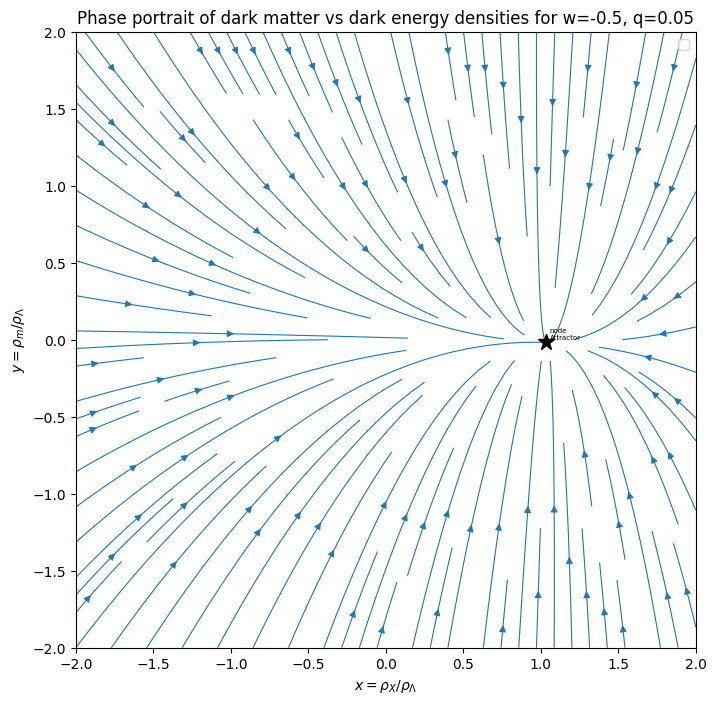

In [3]:
#plotting phase portrait at lambda slice
def phase_plot(w, q):
  def system(t, vars):
      x, y = vars

      #w_x = w - (1 + w)/(x+1e-8)
      
      dx =-3*(1+w)*(x-1) + q*(x-y)
      dy =-3*y - q*(x-y)

      return [dx, dy]

  # plot the dynamics on graph
  initialState=np.array([10, 100])

  simulationTime=np.linspace(-10,0,500)#  number of e folds of time, inflation lasted 50-60
  # generate the state-space trajectory

  def stop_event(t, y):
      x, y_ = y
      return abs(x) - 1e-6  # stop near singularity

  stop_event.terminal = True

  sol = solve_ivp(system, [-10,0], initialState , t_eval=simulationTime)#  for initial conditions matter (y) now ~0.4 and so DM (x) ~0.6. For early time, large x for DE domination and 
  #large y for matter epochs. Using present values, y(-50)=0.4e^(-3*-50) and x(-50)=0.6e^(-3(1+w))
  dx = sol.y[0]
  dy = sol.y[1]
  a = np.exp(sol.t)  # scale factor

  # defining a grid of points at which we create/compute tangent arrows
  x0 = np.linspace(-2,2,10)
  x1 = np.linspace(-2,2,10)
  X0,X1 = np.meshgrid(x0,x1)
  dX0 = np.zeros(X0.shape)
  dX1 = np.zeros(X1.shape)

  for i in range(X0.shape[0]):
      for j in range(X0.shape[1]):
              dx,dy= system(0,[X0[i,j], X1[i,j]])
              dX0[i,j] = dx
              dX1[i,j] = dy

# in order to plot trajectories of solutions from fixed points, using sympy to solve the equations dx and dy =0 and 
# finding values of x and y. These can then be used in a jaconian matrix to determine eigenvalues at these fixed points which 
# determines stability.  

  x_FP, y_FP = sp.symbols('x y ', real=True)

  #w_x = w_a - (1 + w_a)/x_FP
  f =-3*(1+w)*(x_FP-1) + q*(x_FP-y_FP)
  g =-3*y_FP - q*(x_FP-y_FP)
  J_sym = sp.Matrix([f, g]).jacobian([x_FP, y_FP]) # Symbolic Jacobian for x and y 2D

  solutions = sp.solve([f, g], [x_FP, y_FP], dict=True)
  FP=[]
  for sol in solutions:
    if x_FP in sol and y_FP in sol:
      x_val = sol[x_FP]
      y_val = sol[y_FP]
      #z_val = sol[z_FP]
      #lam_val = sol[lam_FP]
      if x_val.is_real and y_val.is_real:
          x_val,y_val = float(x_val),float(y_val)
          FP.append([float(x_val),float(y_val)])
  print("Physical fixed points:", FP)

  plt.figure(figsize=(8,8))
  plt.streamplot(X0, X1, dX0, dX1, density=1.2, linewidth=0.8)
  #plt.plot(x_vals, y_vals, 'r', lw=2, label='Trajectory')
  #plt.plot(x_vals[0], y_vals[0], 'ro', label='Initial condition')


# classifying E vals in accordance with dynamical system analysis
  def classify_FP(eigvals,temp=1e-10):
    Real = np.real(eigvals)
    Imag = np.imag(eigvals)
    if np.all(Real<-temp):
      stability = 'Attractor'
    elif np.all(Real>temp):
      stability = 'Repeller'
    elif np.any(Real<-temp) and np.any(Real > temp):
      stability = 'saddle'
    elif np.all(np.abs(Real) < temp):
      stability = 'Centre'
    else:
      stability = 'NaN'
    if np.any(np.abs(Imag)>temp):
      point_type = 'Spiral'
    else:
      point_type = 'node'

    return stability,point_type

# plotting the fixed points by determining their eigenvalues and then classifying them using the above function
  for fp in FP:
    x_c, y_c = fp
    J_num = np.array(J_sym.subs({x_FP: x_c,y_FP: y_c}),dtype=float)
    eigvals,eigvecs = np.linalg.eig(J_num)
    stability,point_type = classify_FP(eigvals)
    print(f'Fixed points ({x_c:},{y_c})')
    print('Eigen Values:',eigvals)
    print(f'Type={point_type}')
    print(f'Stability={stability}\n')
    plt.plot(x_c, y_c, 'k*', markersize=12)
    plt.text(x_c+0.02, y_c+0.02, f"{point_type}\n{stability}", fontsize=5)

# a separatrix is plotted from a saddle point and divides areas of different dynamics along the eigenvector direction


    if stability=='saddle': 
       delta=1e-5 # small perturbations along eigenvector
       for vector,value in zip(eigvecs.T,eigvals):
          if value>0:
             for pm in [-1,1]: #either positive of negative direction
              x_start = np.array([x_c,y_c])+pm*delta*vector[:2]
              trajectory= solve_ivp(fun=system,t_span=(simulationTime[0], simulationTime[-1]),y0=x_start,t_eval=simulationTime,method='RK45',events=stop_event)
              plt.plot(trajectory.y[0],trajectory.y[1],'r--',linewidth=1)
    

  plt.xlabel(r"$x = \rho_X/ \rho_\Lambda$")
  plt.ylabel(r"$y=\rho_m/ \rho_\Lambda$")
  plt.title(rf"Phase portrait of dark matter vs dark energy densities for w={w}, q={q}")
  #plt.xlim(-1.5,1.5)
  #plt.ylim(-1.5,1.5)
  plt.legend()
  plt.show()





# try w=-0.95 and -0.5 and q=+- 0.05
phase_plot(-0.5,0.05)

# https://aleksandarhaber.com/phase-portraits-of-state-space-models-and-differential-equations-in-python/, https://www.youtube.com/watch?v=DeeoiE22bZ8, method from https://iopscience.iop.org/article/10.1088/1475-7516/2018/01/018/meta


#### Plot of x vs y vs $w_{eff}$

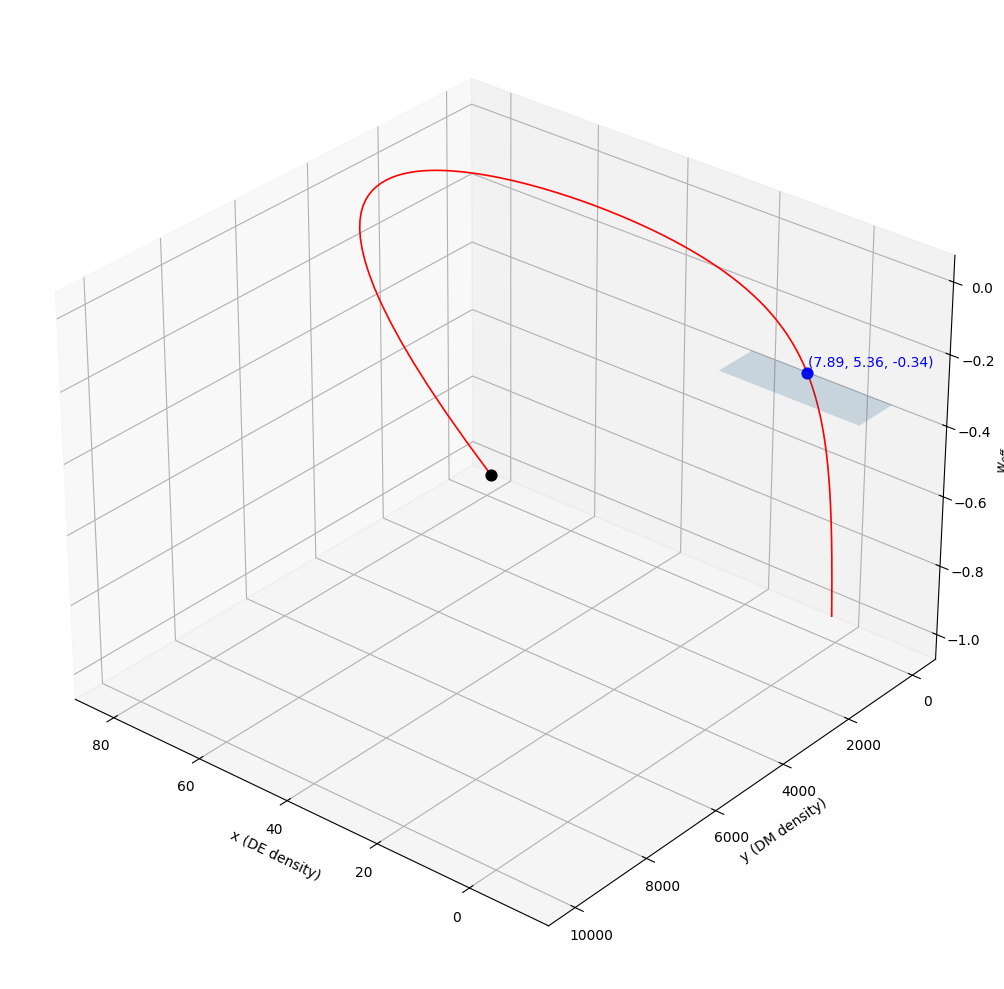

In [4]:
w,q=-0.5,-0.05



def system(t, vars):
      x, y = vars

      #w_x = w - (1 + w)/(x+1e-8)
      
      dx =-3*(1+w)*(x-1) + q*(x-y)
      dy =-3*y - q*(x-y)

      return [dx, dy]

  # plot the dynamics on graph
initialState=np.array([1, 10000]) # x~1   y=y0e^-3N~1e13

simulationTime=np.linspace(-10,0,500)#  number of e folds of time, inflation lasted 50-60
  # generate the state-space trajectory

sol = solve_ivp(system, [-10,0], initialState , t_eval=simulationTime)#  for initial conditions matter (y) now ~0.4 and so DM (x) ~0.6. For early time, large x for DE domination and 
  #large y for matter epochs. Using present values, y(-50)=0.4e^(-3*-50) and x(-50)=0.6e^(-3(1+w))
x = sol.y[0]
y = sol.y[1]
weff=((w*(x-1)-1)/(x+y))

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.plot3D(x, y, weff, color='r', lw=1.2)
ax.scatter3D(x[0], y[0], weff[0], color='black', s=60)

a = np.linspace(-10, 20, 100)
b = np.linspace(-10, 1000, 10000)
X, Y = np.meshgrid(a, b)
Z = np.ones(X.shape) * -1/3
ax.plot_surface(X, Y, Z, alpha=0.2)

idx = np.where(np.isclose(weff, -1/3, atol=3e-3))[0]
for i in idx:
    ax.scatter3D(x[i], y[i], weff[i], color='blue', s=60)
    ax.text(x[i]+0.02, y[i]+0.02, weff[i]+0.02, f"({x[i]:.2f}, {y[i]:.2f}, {weff[i]:.2f})", color='b')

      

ax.set_xlabel("x (DE density)")
ax.set_ylabel("y (DM density)")
ax.set_zlabel("$w_{eff}$")
ax.view_init(elev=30, azim=130)
plt.tight_layout()
plt.show()

## Using H normalised variables
#### from the affine equation of state we find $\rho_X=\rho_{dyn}+\rho_\Lambda$
#### so the Friedmann equation, $H^2 = 1/3 (\rho_m+\rho_X) =1/3 (\rho_{dyn}+\rho_m +\rho_\Lambda)$, becomes 1=x+y+z where:

#### $x=\frac{\rho_{dyn}}{3H^2}$, $y=\frac{\rho_{m}}{3H^2}$, $z=\frac{\rho_{\Lambda}}{3H^2}$ with ranges $0\leq x,y,z \leq 1 $
#### using these variables, we find that the continuity equations become a 2D system using the Friedmann constaint z=1-x-y and using the interaction term $Q=qH(\rho_X-\rho_m)$

#### $x' = 3(1+w)(x^2-x)+3xy+q(1-2y)$
#### $y' = 3(y^2-y)+3xy(1+w) -q(1-2y)$

#### $w_{eff} = \frac{P_X}{\rho_X+\rho_m}=\frac{w(\rho_X-\rho_\Lambda)-\rho_\Lambda}{\rho_X+\rho_m}$
#### $w_{eff} = \frac{wx-z}{x+y+z}= (1+w)x+y-1$

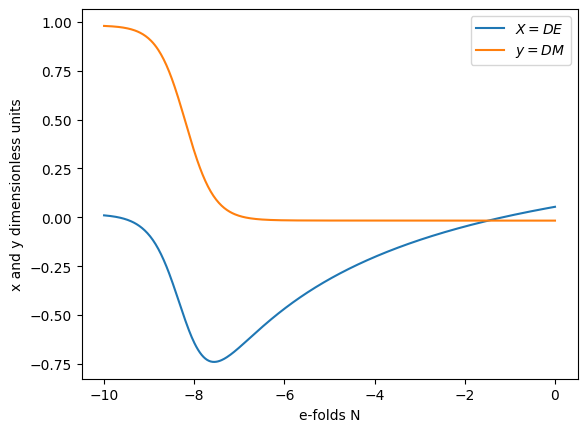

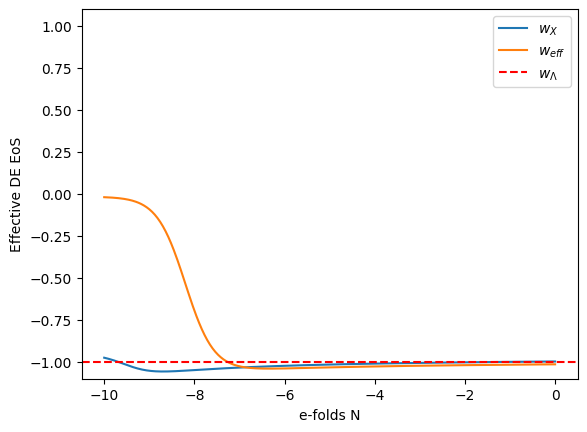

In [5]:
w,q =-0.95,0.05

def system(t,vars):
    x,y=vars
    dx= 3*(1+w)*(x**2-x)+3*x*y+q*(1-2*y)#dynamic evolving DE
    dy=3*(y**2-y)+3*x*y*(1+w) -q*(1-2*y)#dynamic DM
    
    return [dx,dy]

simulationTime=np.linspace(-10,0,500)
solution = solve_ivp(system,[-10,0],[0.01,0.98],t_eval=simulationTime)
x=solution.y[0]
y=solution.y[1]
wx= ((1+w)*x +y-1)/(1-y+1e-6)
weff=(1+w)*x +y-1



plt.figure()
plt.plot(simulationTime, x, label=r'$X=DE$')
plt.plot(simulationTime, y, label=r'$y=DM$')
plt.xlabel('e-folds N')
plt.ylabel('x and y dimensionless units')
#plt.xscale('log')  # log scale to show early universe
plt.legend()

plt.figure()
plt.plot(simulationTime, wx, label=r'$w_X$')
plt.plot(simulationTime, weff, label=r'$w_{eff}$')
plt.axhline(y=-1, color='r', linestyle='--', label=r'$w_\Lambda$')
plt.xlabel('e-folds N')
plt.ylabel('Effective DE EoS')
plt.ylim(-1.1,1.1)
#plt.xscale('log')
plt.legend()
plt.show()

## 3D plot of x and y

Detected fixed points: [array([ 0.344828, -0.017241]), array([0.017236, 0.982764])]
Fixed points (0.344828,-0.017241)
Eigen Values: [-0.0991218 -2.9508746]
Type=node
Stability=Attractor

Fixed points (0.017236,0.982764)
Eigen Values: [2.8517548 2.9508774]
Type=node
Stability=Repeller



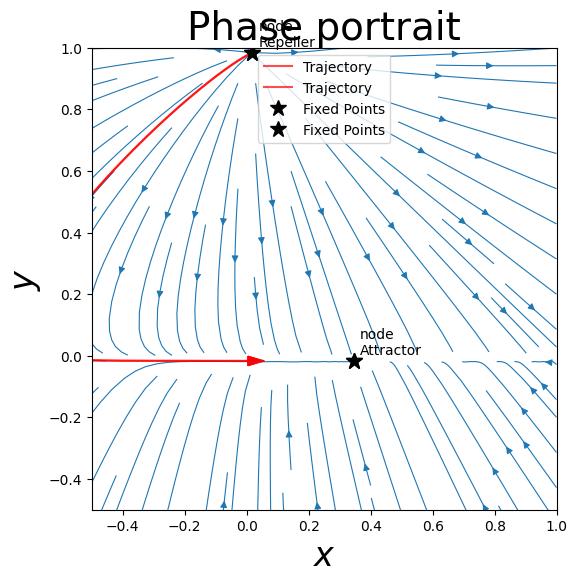

In [10]:
w,q =-0.95,0.05

def system(t,vars):
    x,y=vars
    dx= 3*(1+w)*(x**2-x)+3*x*y+q*(1-2*y)#dynamic evolving DE
    dy=3*(y**2-y)+3*x*y*(1+w) -q*(1-2*y)#dynamic DM
    
    return [dx,dy]



simulationTime=np.linspace(-10,0,500)#  number of e folds of time, inflation lasted 50-60
# generate the state-space trajectory
ICs=[0.01,0.98]

def traj(IC): # change to forward time -50,50 for expanding and 50,-50 reverse time for contracting
    sol = solve_ivp(system, t_span=(simulationTime[0],simulationTime[-1]), y0=ICs,t_eval=simulationTime, method='RK45', rtol=1e-6, atol=1e-6)
    return sol

def plot_traj(sol):
    x = sol.y[0]
    y = sol.y[1]

    plt.plot(x,y ,color='r',alpha = 0.7,label="Trajectory")
    x0,y0 = x[-2],y[-2]
    X_diff=x[-1] -x[-2]
    Y_diff=y[-1] -y[-2]
    plt.arrow(x0, y0, X_diff, Y_diff, head_width=0.03, head_length=0.05, length_includes_head=True, color='r')


#plotting phase portrait 
def phase_plot():

  FP = find_fixed_points()
  

  
  print("Detected fixed points:",FP)


  # defining a grid of points at which we create/compute tangent arrows
  x0 = np.linspace(-0.999,0.999,100)
  x1 = np.linspace(-0.999,0.999,100)
  X0,X1 = np.meshgrid(x0,x1)
  dX0 = np.zeros(X0.shape)
  dX1 = np.zeros(X1.shape)

  for i in range(X0.shape[0]):
      for j in range(X0.shape[1]):
                if abs(X0[i,j]) >= 1 or abs(X1[i,j]) >= 1:
                  dX0[i,j] = 0
                  dX1[i,j] = 0
                else:
                  dx,dy = system(0,[X0[i,j], X1[i,j]])
                  dX0[i,j] = dx
                  dX1[i,j] = dy

  plt.figure(figsize=(6,6))
  plt.streamplot(X0, X1, dX0, dX1, density=1.2, linewidth=0.8)
  #plt.plot(x_vals, y_vals, 'r', lw=2, label='Trajectory')
  #plt.plot(x_vals[0], y_vals[0], 'ro', label='Initial condition')

  initial_conditions = [(0.99, 0), (0, 0.99)]
  for dx0,dy0 in initial_conditions:
        sol = traj([dx0,dy0])
        plot_traj(sol)


  def classify_FP(eigvals,temp=1e-10):
    Real = np.real(eigvals)
    Imag = np.imag(eigvals)
    if np.all(Real<-temp):
      stability = 'Attractor'
    elif np.all(Real>temp):
      stability = 'Repeller'
    elif np.any(Real<-temp) and np.any(Real > temp):
      stability = 'saddle'
    elif np.all(np.abs(Real) < temp):
      stability = 'Centre'
    else:
      stability = 'NaN'
    if np.any(np.abs(Imag)>temp):
      point_type = 'Spiral'
    else:
      point_type = 'node'

    return stability,point_type

  for fp in FP:
    x_c, y_c = fp
    plt.plot(x_c, y_c, 'k*', markersize=12)
    delta = 1e-6
    if abs(x_c) >= 1 or abs(y_c) >= 1:

        stability = "saddle"
        point_type = "Boundary"

        starts = [
                [x_c-delta,y_c],
                [x_c,y_c-delta],
                [x_c-delta,y_c-delta],
                [x_c-delta,y_c+delta]
            ]

        for start in starts:

                start = np.clip(start,-0.999,0.999)

                sol = solve_ivp(system,(-10, 0),start,t_eval=simulationTime)
                plt.plot(sol.y[0], sol.y[1], 'r--')

        continue



    
    # creating a numerical jacobian because the sympy function doesnt work when functions blow up to infinities at +-1

    eps=1e-6
    fx1 = system(0,[x_c+eps,y_c])
    fx2 = system(0,[x_c-eps,y_c])

    fy1 = system(0,[x_c,y_c+eps])
    fy2 = system(0,[x_c,y_c-eps])

    J = np.array([
            [(fx1[0]-fx2[0])/(2*eps),(fy1[0]-fy2[0])/(2*eps)],
            [(fx1[1]-fx2[1])/(2*eps),(fy1[1]-fy2[1])/(2*eps)]
        ])

    eigvals,eigvecs = np.linalg.eig(J)

    stability,point_type = classify_FP(eigvals)




    print(f'Fixed points ({x_c:},{y_c:})')
    print('Eigen Values:',eigvals)
    print(f'Type={point_type}')
    print(f'Stability={stability}\n')
    plt.plot(x_c, y_c, 'k*', markersize=12,label='Fixed Points')
    plt.text(x_c+0.02, y_c+0.02, f"{point_type}\n{stability}", fontsize=10)

  
  plt.xlabel(rf"$x$",fontsize=24)
  plt.ylabel(rf"$y$",fontsize=24)
  plt.title(rf"Phase portrait",fontsize=28)
  plt.xlim(-0.5,1)
  plt.ylim(-0.5,1)


  plt.legend()
  
  plt.show()





def find_fixed_points():
    guesses = np.linspace(-0.9,0.9,40)
    FP = []
    for g1 in guesses:
        for g2 in guesses:
            sol = root(lambda v: system(0,[v[0],v[1]]), [g1,g2])
            if sol.success:
                x, y = sol.x

                if abs(x) < 1 and abs(y) < 1:
                    dx,dy = system(0,[x,y])

                    if abs(dx) < 1e-6 and abs(dy) < 1e-6:
                        pt = np.round([x,y],6)

                        if not any(np.allclose(pt,p,atol=1e-4) for p in FP):
                            FP.append(pt)

    return FP


phase_plot()

# https://aleksandarhaber.com/phase-portraits-of-state-space-models-and-differential-equations-in-python/, https://www.youtube.com/watch?v=DeeoiE22bZ8, method from https://iopscience.iop.org/article/10.1088/1475-7516/2018/01/018


### Includes radiation factor

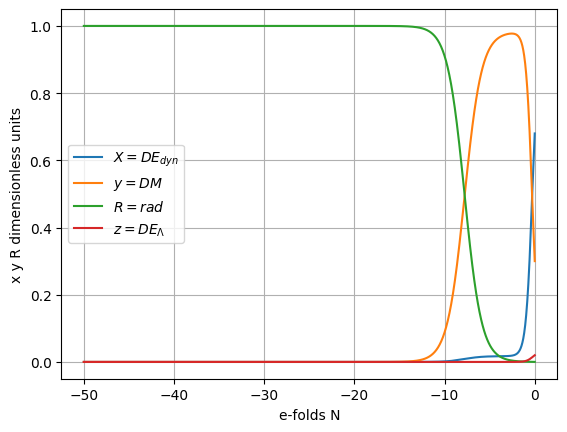

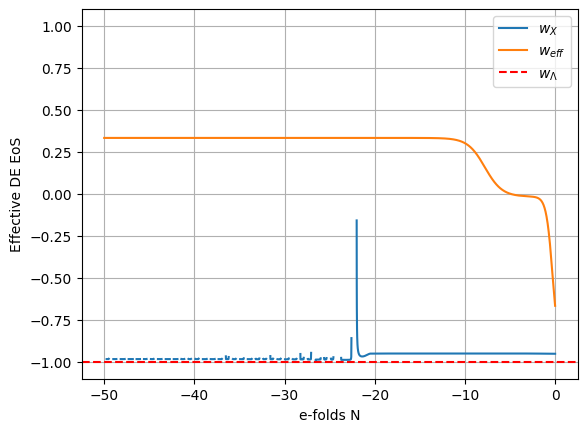

In [7]:
w,q =-0.95,0.05


def system(t,vars):
    x,y,R=vars
    dx= 3*(1+w)*(x**2-x)+3*x*y+q*(1-2*y-R)+4*x*R #dynamic evolving DE
    dy=3*(y**2-y)+3*x*y*(1+w) -q*(1-2*y-R)+4*y*R #dynamic DM
    dR = -4*R+(1+w)*3*x*R +3*y*R+4*R**2
    #   to plot standard Lambda CDM, set q=0, w=-1 and get rid of xR,yR and R^2 terms. 
    return [dx,dy,dR]

simulationTime=np.linspace(0,-50,5000)
solution = solve_ivp(system,[0,-50],[0.68,0.3,9e-5],method='RK45',t_eval=simulationTime,rtol=1e-6,atol=1e-6)# using standard modern observational fractions
x=solution.y[0]
y=solution.y[1]
R=solution.y[2]

z=1-x-y-R
#wx = ((w*x - z) / (x + z ))
wx = np.full_like(x, np.nan)

mask = (x+z)  > 1e-10   # only compute where valid

wx[mask] = (w*x[mask] - z[mask]) / (x+z)[mask]

#wx= ((1+w)*x-1+y+R)/(1-y-R)
weff=(1+w)*x+4/3 *R +y-1


plt.figure()
plt.plot(simulationTime, x, label=r'$X=DE_{dyn}$')
plt.plot(simulationTime, y, label=r'$y=DM$')
plt.plot(simulationTime, R, label=r'$R=rad$')
plt.plot(simulationTime, z, label=r'$z=DE_\Lambda$')
plt.xlabel('e-folds N')
plt.ylabel('x y R dimensionless units')
#plt.xscale('log')  # log scale to show early universe
plt.legend()
plt.grid()


plt.figure()
plt.plot(simulationTime, wx, label=r'$w_X$')
plt.plot(simulationTime, weff, label=r'$w_{eff}$')
plt.axhline(y=-1, color='r', linestyle='--', label=r'$w_\Lambda$')
plt.xlabel('e-folds N')
plt.ylabel('Effective DE EoS')
plt.ylim(-1.1,1.1)
#plt.xscale('log')
plt.legend()
plt.grid()

plt.show()

Graph A shows the combined evolution of the radiation, matter and dynamical dark energy densities, normalised with respect to the Hubble parameter. It shows large radiation domination era from -50 to -10 epochs in accordance with Lambda CDM observations. Then a matter domination era from -10 to -0.7 epochs (somewhat different due to interaction term keeping matter relevant for longer) and then dark energy domination from then on up until present day.

Graph B presents the evolving effective and dark energy equations of state. weff is the effective equation of state and takes the value of 1/3 for the radiation dominated era as matter and DE are minimal, but then dips during the matter domination era but not to exactly 0 as there are DE adn DM interactions forcing it lower, and then finally it tends towards ~-1 for late times during DE domination. In here, the $w_X$ at early and middle times looks to oscillate, this is due to the nature of the coupling term. It is resorative and so naturally has sign changes that becomes increasingly more frequent as the matter component becomes more relevant. Up until around N=-20 where matter is not dominating but is increasingly relevant, but late enough in the evolution that the affine parameter term $w$ comes to dominate the equation $w_X=w-(1+w)\frac{\rho_\Lambda}{\rho_X}$. This is of little consequence to the overall dynamics as DE at this point is dynamically irrelevant. 

## Phase plot of xyR

Fixed points: [[0.01723616731230882, 0.9827638326876912, 0.0], [0.3448275862068966, -0.017241379310344827, 0.0], [1.0178515519859368, -0.01785155198593679, 0.0], [0.0, 0.0, 1.0]]
FP [0.01723616731230882, 0.9827638326876912, 0.0] → Saddle, eig=[ 2.85175385  2.95087692 -1.04912308]
FP [0.3448275862068966, -0.017241379310344827, 0.0] → Attractor, eig=[-0.09912308 -2.95087692 -4.        ]
FP [1.0178515519859368, -0.01785155198593679, 0.0] → Saddle, eig=[ 0.09912308 -2.85175385 -3.90087692]
FP [0.0, 0.0, 1.0] → Repeller, eig=[3.90087692 4.         1.04912308]


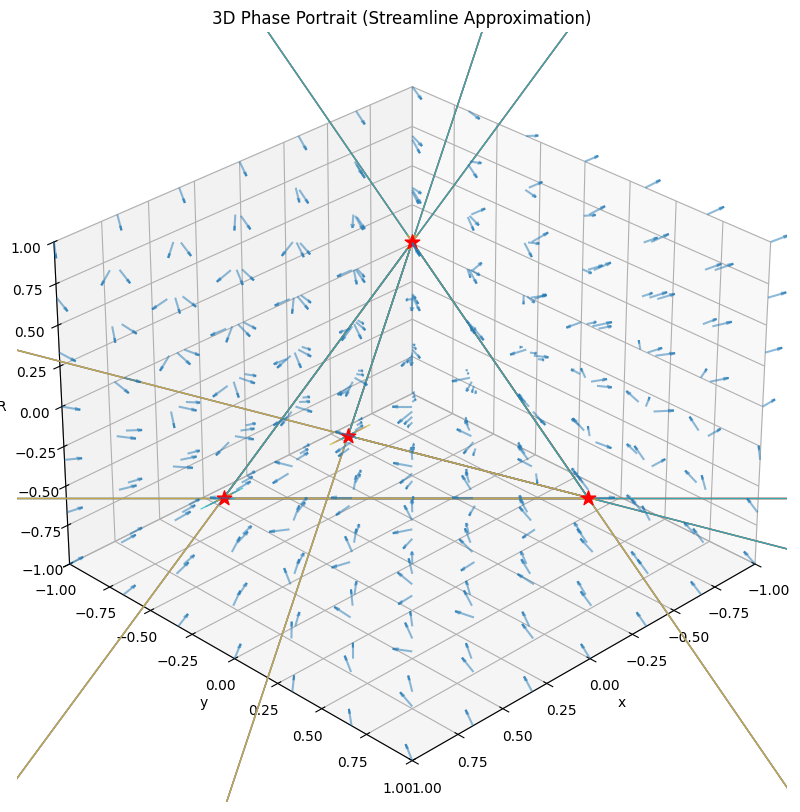

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sympy as sp

# -----------------------------
# PARAMETERS
# -----------------------------
w, q = -0.95, 0.05

# -----------------------------
# SYSTEM
# -----------------------------
def system(t, vars):
    x, y, R = vars

    dx = 3*(1+w)*(x**2 - x) + 3*x*y + q*(1 - 2*y - R) + 4*x*R
    dy = 3*(y**2 - y) + 3*x*y*(1+w) - q*(1 - 2*y - R) + 4*y*R
    dR = -4*R + 3*(1+w)*x*R + 3*y*R + 4*R**2

    return [dx, dy, dR]

# -----------------------------
# TIME
# -----------------------------
simulationTime = np.linspace(0, -50, 2000)

# -----------------------------
# MAIN PLOT FUNCTION
# -----------------------------
def phase_plot_3D():

    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(111, projection='3d')

    ax.set_title("3D Phase Portrait (Streamline Approximation)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("R")
    # -----------------------------
    # VECTOR FIELD (ARROWS)
    # -----------------------------
    grid_n = 7

    xg = np.linspace(-1, 1, grid_n)
    yg = np.linspace(-1, 1, grid_n)
    Rg = np.linspace(-1, 1, grid_n)

    X, Y, Z = np.meshgrid(xg, yg, Rg)

    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    W = np.zeros_like(Z)

    for i in range(grid_n):
        for j in range(grid_n):
            for k in range(grid_n):
                vec = system(0, [X[i,j,k], Y[i,j,k], Z[i,j,k]])
                U[i,j,k], V[i,j,k], W[i,j,k] = vec

    # normalize arrows (important!)
    mag = np.sqrt(U**2 + V**2 + W**2) + 1e-10
    U, V, W = U/mag, V/mag, W/mag

    ax.quiver(
        X, Y, Z,
        U, V, W,
        length=0.08,
        normalize=True,
        alpha=0.5
    )





    # -----------------------------
    # SYMBOLIC FIXED POINTS
    # -----------------------------
    x_FP, y_FP, R_FP = sp.symbols('x y R', real=True)

    f = 3*(1+w)*(x_FP**2 - x_FP) + 3*x_FP*y_FP + q*(1 - 2*y_FP - R_FP) + 4*x_FP*R_FP
    g = 3*(y_FP**2 - y_FP) + 3*x_FP*y_FP*(1+w) - q*(1 - 2*y_FP - R_FP) + 4*y_FP*R_FP
    h = -4*R_FP + 3*(1+w)*x_FP*R_FP + 3*y_FP*R_FP + 4*R_FP**2

    J = sp.Matrix([f, g, h]).jacobian([x_FP, y_FP, R_FP])

    solutions = sp.solve([f, g, h], [x_FP, y_FP, R_FP], dict=True)

    FP = []
    for sol in solutions:
        try:
            x_val = float(sol[x_FP])
            y_val = float(sol[y_FP])
            R_val = float(sol[R_FP])

            if x_val + y_val + R_val <= 1.0 + 1e-6:
                FP.append([x_val, y_val, R_val])
        except:
            pass

    print("Fixed points:", FP)

    # -----------------------------
    # CLASSIFY
    # -----------------------------
    def classify(eigvals):
        real = np.real(eigvals)
        if np.all(real < 0):
            return "Attractor"
        elif np.all(real > 0):
            return "Repeller"
        else:
            return "Saddle"

    # -----------------------------
    # STREAMLINE-LIKE TRAJECTORIES
    # -----------------------------
    for fp in FP:

        x_c, y_c, R_c = fp

        J_num = np.array(J.subs({x_FP: x_c, y_FP: y_c, R_FP: R_c}), dtype=float)
        eigvals, eigvecs = np.linalg.eig(J_num)

        stability = classify(eigvals)

        print(f"FP {fp} → {stability}, eig={eigvals}")

        ax.scatter(x_c, y_c, R_c, color='red', s=120, marker='*')

        # -----------------------------
        # LOCAL STREAMLINES AROUND FP
        # -----------------------------
        delta = 0.02

        for i in range(3):
            v = np.real(eigvecs[:, i])
            v = v / np.linalg.norm(v)

            for pm in [-1, 1]:

                # multiple offsets → dense "flow"
                for scale in np.linspace(0.5, 2.0, 5):

                    x_start = np.array([x_c, y_c, R_c]) + pm * delta * scale * v

                    # forward + backward integration
                    for t_span in [(0, -10), (0, 10)]:

                        sol = solve_ivp(
                            system,
                            t_span,
                            x_start,
                            t_eval=np.linspace(t_span[0], t_span[1], 300),
                            rtol=1e-6,
                            atol=1e-6
                        )

                        ax.plot(
                            sol.y[0],
                            sol.y[1],
                            sol.y[2],
                            linewidth=1,
                            alpha=0.7
                        )

    ax.set_xlim([-1,1])
    ax.set_ylim([-1,1])
    ax.set_zlim([-1,1])
    ax.view_init(elev=30, azim=45)
    plt.show()


# -----------------------------
# RUN
# -----------------------------
phase_plot_3D()


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


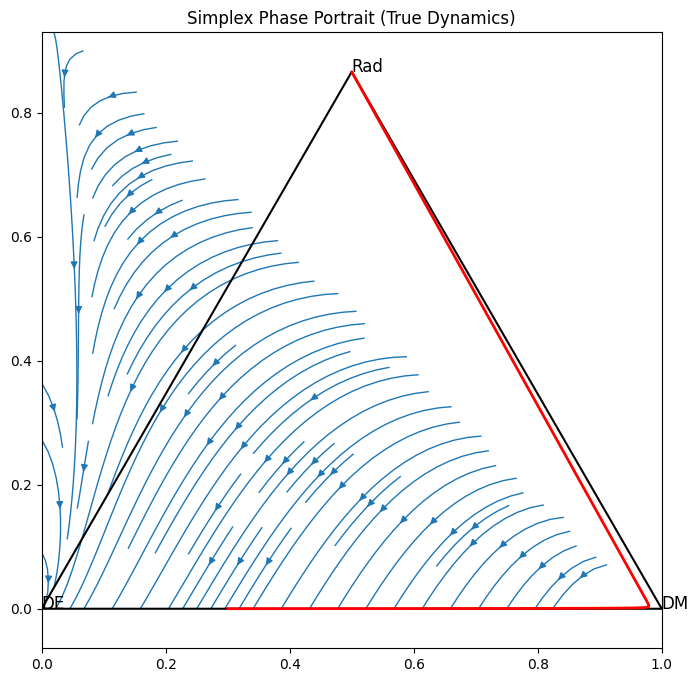

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# -----------------------------
# PARAMETERS
# -----------------------------
w, q = -0.95, 0.05

# -----------------------------
# SYSTEM (same physics)
# -----------------------------
def system(N, vars):
    x, y, R = vars

    dx = 3*(1+w)*(x**2-x) + 3*x*y + q*(1-2*y-R) + 4*x*R
    dy = 3*(y**2-y) + 3*x*y*(1+w) - q*(1-2*y-R) + 4*y*R
    dR = -4*R + 3*(1+w)*x*R + 3*y*R + 4*R**2

    return [dx, dy, dR]

# -----------------------------
# SIMPLEX PROJECTION
# -----------------------------
def project(x, y, R):
    X = y + 0.5 * R
    Y = (np.sqrt(3)/2) * R
    return X, Y

# -----------------------------
# GRID IN SIMPLEX
# -----------------------------
n = 40
x_vals = np.linspace(0, 1, n)
y_vals = np.linspace(0, 1, n)

X_grid, Y_grid = np.meshgrid(x_vals, y_vals)

U = np.zeros_like(X_grid)
V = np.zeros_like(Y_grid)

for i in range(n):
    for j in range(n):
        x = X_grid[i,j]
        y = Y_grid[i,j]
        R = 1 - x - y

        if R < 0:
            U[i,j] = np.nan
            V[i,j] = np.nan
            continue

        dx, dy, dR = system(0, [x, y, R])

        # project derivatives
        dX = dy + 0.5*dR
        dY = (np.sqrt(3)/2)*dR

        U[i,j] = dX
        V[i,j] = dY

# -----------------------------
# PLOT STREAMLINES
# -----------------------------
plt.figure(figsize=(8,8))

plt.streamplot(
    X_grid, Y_grid,
    U, V,
    density=1.5,
    linewidth=1
)

# -----------------------------
# PLOT TRIANGLE BOUNDARY
# -----------------------------
triangle = np.array([
    project(1,0,0),
    project(0,1,0),
    project(0,0,1),
    project(1,0,0)
])

plt.plot(triangle[:,0], triangle[:,1], 'k')

# label corners
plt.text(*project(1,0,0), "DE", fontsize=12)
plt.text(*project(0,1,0), "DM", fontsize=12)
plt.text(*project(0,0,1), "Rad", fontsize=12)

# -----------------------------
# TRAJECTORY
# -----------------------------
t = np.linspace(0, -50, 2000)
sol = solve_ivp(system, [0,-50], [0.68,0.3,1e-4], t_eval=t)

Xp, Yp = project(sol.y[0], sol.y[1], sol.y[2])
plt.plot(Xp, Yp, 'r', lw=2)

plt.title("Simplex Phase Portrait (True Dynamics)")
plt.axis('equal')
plt.xlim(0,1)
plt.ylim(0,np.sqrt(3)/2)

plt.show()